# **<u>Kinetyka chemiczna</u>: reakcja Braya-Liebhafsky'ego**

****
## **Spis treści** <a id="spistresci"></a>
1. [Wstęp](#wstep)
    1. [Kinetyka chemiczna $-$ wprowadzenie](#1wstep1)
    2. [Oscylacje w chemii](#2wstep2)
    3. [Krótko o historii](#3wstep3)
    4. [Cele projektu](#4wstep4)
2. [Podstawy teoretyczne](#podstawy)
    1. [Wyjaśnienie pojęć](#1teoria)
    2. [Opis modelu](#2teoria)
3.  [Metody numeryczne](#metody)
    1. [Implementacja metody Eulera](#euler) 
    1. [Implementacja metody Rungego-Kutty czwartego rzędu](#rk4)
    2. [Opis metody Runge-Kutty Dormanda-Prince'a](#rk45)
4. [Rozwiązanie modelu reakcji Braya-Liebhafsky'ego](#rozw)
5. [Porównanie metod numerycznych](#numeryka)
    1. [Porównanie rozwiązań](#porownanie) 
    2. [Analiza błędów](#bledy)
6. [Podsumowanie i wnioski](#podsumowanie)
7. [Bibliografia](#bibliografia)

***
## **1. Wstęp** <a id="wstep"></a>

### 1.1 Kinetyka chemiczna $-$ wprowadzenie <a id="1wstep1"></a>

Kinetyka chemiczna to dział chemii, konkretnie chemii fizycznej, badający przebieg reakcji chemicznych. Różni się jednak od termodynamiki podejściem do problemu: termodynamika pozwala przewidzieć kierunek zachodzenia reakcji czy określić jej wydajność i bilans energetyczny, ale nie zapewnia informacji o samym procesie. Kinetyka natomiast skupia się na szybkości reakcji i zmianach stężeń związków chemicznych, co pozwala zrozumieć mechanizm przebiegu reakcji i określić wpływ czynników takich jak np.: temperatura czy obecność katalizatorów na kierunek i tempo reakcji [[5](#ref5)].

### 1.2 Oscylacje w chemii <a id="2wstep2"></a>

Możliwość badania mechanizmu reakcji jest szczególnie przydatna w przypadku zajmowania się reakcjami, w których występują oscylacje stężeń. Są one ciekawym typem przemian chemicznych, ponieważ w większości zjawisk stężenia substancji biorących udział w przemianie dążą do określonego stanu równowagi i pozostają w nim, dopóki nie wpłyniemy na reakcję, np.: dodając więcej któregoś ze związków. Mimo to, w szczególnych warunkach, mogą zachodzić reakcje, w których stężenia długo oscylują wokół stanu równowagi, zanim się w nim zatrzymają. Czasami takie wahania można zaobserwować gołym okiem, przykładowo po zmianie koloru badanego roztworu - tak jak w reakcji Biełausowa-Żabotyńskiego. W innych przypadkach zmiany wizualne są zbyt subtelne i należy badać ilość substancji w odpowiednich przedziałach czasowych [[6](#ref6)]. Określając zmiany stężeń w jednostkach czasu używamy metod kinetyki chemicznej.

### 1.3 Krótko o historii <a id="3wstep3"></a>

Historycznie uważano, że oscylacje nie mają prawa występować w reakcjach chemicznych, a ich obserwacje są wynikiem przypadku lub nieodpowiedniego przygotowania do eksperymentu [[6](#ref6)]. Ponad 100 lat temu praca Wiliama C. Braya potwierdziła jednak, że wahania stężeń reagentów są możliwe nawet w roztworze jednorodnym [[7](#ref7)] i stała się inspiracją do dalszych badań nad oscylacjami w chemii. Badania nad wspomnianą reakcją utleniania-redukcji związków jodu były przez niego kontynuowane, wraz z jego uczniem $-$ Hermanem Liebhafskym [[8](#ref8)].

### 1.4 Cele projektu <a id="4wstep4"></a>

Celem naszej pracy jest przybliżenie ciekawego problemu reakcji oscylacyjnych, na przykładzie pierwszej opisanej takiej reakcji chemicznej i pokazanie, że mimo, iż sam proces przebiegający podczas reakcji Braya-Liebhafsky'ego jest skomplikowany, to można modelować go matematycznie, znacznie upraszczając zagadnienie. Pokażemy, jak można rozwiązywać układy równań różniczkowych za pomocą różnych metod numerycznych i porównamy ich wyniki oraz przedstawimy, jak wybrany przez nas model opisuje dynamikę zadanego układu chemicznego.

***
## **2. Podstawy teoretyczne** <a id="podstawy"></a>

### 2.1 Wyjaśnienie pojęć [[5](#ref5)] <a id="1teoria"></a>

Podstawową wielkością badaną w kinetyce chemicznej jest **szybkość reakcji**, oznaczana $v$. Jest ona pochodną stężenia molowego substancji po czasie: 
$$v = \pm{}\dfrac{dc}{dt} .$$
Stężenie molowe, występujące w powyższym równaniu, to miara stężenia związku chemicznego, określająca liczbę moli substancji (liczbę cząsteczek) w jednostce objętości: $c = \dfrac{n}{V}$ . Jest ono także czasem oznaczane wzorem danego związku chemicznego w nawiasie kwadratowym, np.: [$O_2$].

Na szybkość reakcji wpływa wiele czynników, w tym stężenie początkowe reagentów. Wynika to z prawa działania mas i pozwala zapisać **równanie kinetyczne reakcji**: 
$$v=k\cdot{}c_A^{\alpha{}}\cdot{}c_B^{\beta{}}\cdot{}c_C^{\gamma{}},$$
gdzie $A$, $B$, $C$ to substraty (czyli substancje wyjściowe), $\alpha{}$, $\beta{}$, $\gamma{}$ to liczby reagujących cząsteczek odpowiednich związków, a $k$ to **stała szybkości reakcji** (jest ona równa liczbowo szybkości reakcji, gdy stężenia $c_i$ są jednostkowe, a jej wymiar zależy od sumy wykładników $\alpha{}$, $\beta{}$, $\gamma{}$).
Na przykład reakcja $$H_2 + I_2 \xrightarrow{} 2HI$$ ma równanie kinetyczne $$v = k\cdot{}c_{H_2}\cdot{}c_{I_2}.$$

Powyższe informacje są prawdziwe dla reakcji prostych, czyli bedących elementarną przemianą chemiczną. W przypadku reakcji złożonych i wieloetapowych określenie wykładników $\alpha{}$, $\beta{}$, $\gamma{}$ nie jest już takie proste i wymaga wzięcia pod uwagę innych czynników, np.: stosunku szybkości poszczególnych reakcji elementarnych, określanego doświadczalnie. 

Równania kinetyczne są równaniami różniczkowymi pierwszego rzędu i będą podstawą przedstawionego przez nas modelu reakcji Braya-Liebhafsky'ego.

**Reakcje utleniania-redukcji** to reakcje, w których pierwiastki zmieniają stopnie utlenienia, czyli umowne wartości ładunków elementarnych, które miałby atom pierwiastka, zakładając, że wszystkie wiązania w związku chemicznym są jonowe. <br>
**Utlenianie**, inaczej oksydacja, to oddawanie elektronów przez pierwiastek i zwiększenie stopnia utlenienia. Natomiast **redukcja** to przyjmowanie elektronów przez pierwiastek i zmniejszenie stopnia utlenienia. <br>
Podczas reakcji utleniania-redukcji, inaczej reakcji redoks, liczba elektronów pobranych i oddanych przez biorące w niej udział jony musi być jednakowa [[9](#ref9)].

### 2.2 Opis modelu [[1](#ref1)] <a id="2teoria"></a>

Reakcja chemiczna rozpatrywana przez Williama Braya i poźniej również przez Hermana Liebhafsky'ego składa się z dwóch reakcji utleniania-redukcji:
$$
\begin{align}
5H_{2}O_2 + I_2 &\xrightarrow{} 2IO_3^- + 2H^+ + 4H_{2}O \\
5H_{2}O_2 + 2IO_3^- + 2H^+ &\xrightarrow{} I_2 + 5O_2 + 6H_{2}O \space{}.
\end{align}
$$
Pierwsza, reakcja (1), opisuje utlenianie się jodu cząsteczkowego do kwasu jodowego. Druga, reakcja (2), redukcję kwasu jodowego do jodu cząsteczkowego.
Po ich zsumowaniu otrzymujemy:
$$ 2 H_{2}O_2 \xrightarrow{} 2H_{2}O + O_2 \space{},$$
czyli reakcję rozkładu nadtlenku wodoru do wody i tlenu cząsteczkowego [[1](#ref1), [7](#ref7), [8](#ref8)].

Jest to proces autokatalityczny, ponieważ niektóre wytwarzane w trakcie trwania reakcji produkty pośrednie pełnią rolę katalizatorów, czyli przyspieszają przebieg przemian chemicznych. Uważa się, że to autokatalityczna natura reakcji jest znacząca dla wystepowania oscylacji stężeń.


W dalszej części projektu będziemy posługiwać się następującymi zmiennymi, określającymi stężenie molowe oraz dany związek chemiczny:

<div align="center">

<a id="tabela1"></a>

| Zmienna | Wzór chemiczny | Nazwa |
|:---:|:---:|:---:|
| $A$ | $IO_3^-$ | Anion jodanowy |
| $B$ | $H_{2}O_2$ | Nadtlenek wodoru |
| $C$ | $H_{2}O$ | Woda |
| $H$ | $H^+$ | Proton |
| $P$ | $HIO$ | Kwas podjodawy |
| $U$ | $HIO_2$ | Kwas jodawy |
| $V$ | $I^-$ | Anion jodkowy |
| $W$ | $O_2$ | Tlen cząsteczkowy |
| $Z$ | $I_2$ | Jod cząsteczkowy |

Tabela 1. 
</div>



Mimo że przedstawiona wyżej reakcja redoks może wydawać się prosta, to nadal nie poznano jej dokładnego przebiegu. Powstało wiele teorii układów reakcji elementarnych odpowiadających za proces odkryty przez Williama Braya. My użyjemy tego zaproponowanego w [[1](#ref1)]:

$$
\begin{align}
A + V + 2H &\xrightarrow{k_1} U + P\\
U + V + H &\xrightarrow{k_2} 2P\\
3P + U &\xrightarrow{k_3} 2U + Z + C\\
2U &\xrightarrow{k_4} P + A + H\\
Z + C &\xrightarrow{k_5} V + P + H\\
W_{(aq)} &\xrightarrow{k_6} W_{(g)}\\
Z_{(aq)} &\xrightarrow{k_7} Z_{(g)} \space{},
\end{align}
$$

gdzie duże litery odpowiadają nazwom związków zgodnie z  [tabelą 1.](#tabela1)

Mając ten układ siedmiu reakcji możemy zapisać wyrażenia na szybkość reakcji dla rozpatrywanych związków chemicznych. Zacznijmy od $U$, czyli kwasu jodawego $HIO_2$. Jak widać ten związek jest tworzony w reakcji (1) i (3) oraz zużywany w (2) i (4). Oznacza to, że aby otrzymać całkowitą zmianę stężenia $U$ należy dodać równania kinetyczne reakcji (1) i (3) i odjąć równania kinetyczne reakcji (2) i (4): 
$$
\begin{align}
\dfrac{\text{d}U}{\text{d}t} &= v_{1} + v_{3} - v_{2} - v_{4} \space{}, \\
\dfrac{\text{d}U}{\text{d}t} &= k_{1}AVH^2 + k_{3}P^{3}U - k_{2}UVH - k_{4}U^2 \space{} .
\end{align}
$$
Analogicznie postępujemy z pozostałymi zwiazkami.

W przedstawianym przez nas modelu matematycznym [[1](#ref1)] zmienne stężenia $A$, $C$, $H$ i $P$ przybliżono stałymi, odpowiednio $a$, $c$, $h$ i $p$, zakładając, że zmieniają się one dostatecznie wolno. Po zastosowaniu praw kinetyki chemicznej z uwzględnieniem stałych $a$, $c$, $h$ i $p$ otrzymujemy układ czterech równań różniczkowych

$$
\begin{align}
&\dfrac{\text{d}U}{\text{d}t} = k_{1}ah^{2}V + k_{3}p^{3}U
- k_{2}hUV - k_{4}U^2 \space{},\\
&\dfrac{\text{d}V}{\text{d}t} = k_{5}cZ - k_{1}ah^{2}V - k_{2}hUV \space{},\\
&\dfrac{\text{d}Z}{\text{d}t} = k_{3}p^{3}U - (k_{5}c + k_7)Z \space{},\\
&\dfrac{\text{d}W}{\text{d}t} = -k_{6}W \space{}.
\end{align}
$$
<a id="uklad1"></a>
<div align="center">Układ 1.</div>


W modelu [[1](#ref1)] następnie dodano odpowiednie stałe $M_s$ i $T_s$, co pozwoliło uzyskać przedstawiony układ równań w bezwymiarowej formie:

$$
\begin{align}
&\dfrac{\text{d}U}{\text{d}t} = R_{1}V + R_{3}U
- R_{2}UV - R_{4}U^2 \space{},\\
&\dfrac{\text{d}V}{\text{d}t} = R_{5}Z - R_{1}V - R_{2}UV \space{},\\
&\dfrac{\text{d}Z}{\text{d}t} = R_{3}U - (R_{5} + R_7)Z \space{},\\
&\dfrac{\text{d}W}{\text{d}t} = -R_{6}W \space{},
\end{align}
$$
gdzie

$\\ 
R_1 = k_{1}ah^{2}T_s,\\ 
R_2 = k_{2}hM_{s}T_{s}(=1),\\ 
R_3 = k_{3}p^{3}T_s,\\ 
R_4 = k_{4}T_{s}M_{s},\\
R_5 = k_{5}cT_{s}(=1),\\
R_6 = k_{6}T_s,\\
R_7 = k_{7}T_s\\
$

oraz 
$\\
T_s = \dfrac{1}{k_{5}c},\\
M_s = \dfrac{1}{k_{2}hT_s}.
$
<a id="uklad2"></a>
<div align="center">Układ 2.</div>

Warto zauważyć, że w tym momencie stężenia oznaczone dużymi literami są inne od tych w  [układzie 1.](#uklad1), ponieważ zostały przeskalowane przez stałe. Mimo to zdecydowaliśmy pozostać przy tych samych oznaczeniach, zgodnie z zapisem używanym w [[1](#ref1)]. Stałe $T_s$ i $M_s$ zostały dobrane tak, by $R_2$ i $R_5$ były równe $1$. W jednym z przykładów pokażemy, co się dzieje, jeśli jednak zmienimy ich wartości.

W [[1](#ref1)] udowodniono, że badany układ równań, [układ 2.](#uklad2), nie wykazuje zachowań chaotycznych dla żadnych parametrów rzeczywistych. Oznacza to, że nie nadaje on się do modelowania przedstawionej reakcji w warunkach, w których mogą występować w niej chaotyczne zmiany stężeń, np.: w sytuacji, gdy roztwór jest stale mieszany.



Do ilustracji zachowania tego modelu użyjemy trzech zestawów parametrów (wartości początkowych stężeń $U$, $V$, $Z$ i $W$ oraz stałych $R_1, \cdots{}, R_7$), które naszym zdaniem najlepiej pokazują odmienny charakter otrzymywanych rozwiązań. 

***
## **3. Metody numeryczne** <a id="metody"></a>
Metod numerycznych używamy, kiedy rozwiązanie analityczne jest trudne lub niemożliwe do uzyskania. Wtedy przybliżamy rozwiązanie korzystając z algorytmów aproksymujących wartości funkcji w danym punkcie. W tym projekcie przedstawimy metodę 
Eulera oraz metodę Rungego-Kutty czwartego rzędu (RK4). Następnie porównamy otrzymane wyniki z metodą Rungego-Kutty czwartego rzędu Dormanda-Prince'a. 

#### Błędy obcięcia

Błąd lokalny to wielkość odchylenia w pojedyńczym kroku

Błąd globalny to wielkość odchylenia w końcowym momencie. 

### 3.1 Implementacja metody Eulera [[2](#ref2)] <a id="euler"></a>
Jedną z najprostrzych metod numerycznych jest metoda Eulera, która przybliża pochodną funkcji za pomocą różnic skończonych. Jest to metoda pierwszego rzędu. Zakładamy, że zmiana w krótkim okresie czasu ($h$) jest liniowa.

Weźmy pewne równanie różniczkowe:

$ \dfrac{\text{d}y}{\text{d}t}= f(y, t) \space{}.$

Następnie możemy przybliżyć wartość w punkcie $ t_{0} + h $ korzystając z operatora różnic skończonych. Weźmy początkową wartość $ y_{0}, t_{0}$:

$ y'(t_{0} + h) = \dfrac{y(t_{0} + h) - y_{0}}{h} + R = f(t_{0}+h,y)$, gdzie $ R $ to reszta którą pomijamy. Stąd otrzymujemy:

$y(t_{0} + h) = y_{0} + hf(t_{0},y_{0}) \space{}.$

Rekurencyjnie:

$ y_{n + 1} = y_{n} + hf(t_{n}, y_{n}) \space{}.$ 


In [13]:
import numpy as np


def euler_method(fun, t0, y0, h, n_steps, args):
    """
            fun: funkcja przyjmująca argumenty t, y
            t0: wartość początkowa argumentu t
            y0: wartość początkowa funkcji y
            h: wielkość kroku
            n_steps: ilość kroków
            args: parametry modelu
            """
    t = np.linspace(t0, t0 + n_steps * h, n_steps + 1)
    y = np.zeros((n_steps + 1, len(y0)))
    y[0] = y0
    for i in range(n_steps):
        dy = fun(t[i], y[i], *args)
        y[i + 1] = y[i] + h * np.array(dy)
    return t, y

### 3.2 Implementacja metody Rungego-Kutty czwartego rzędu (RK4) <a id="rk4"></a> [[11](#ref11)]
Jest to bardziej zaawansowana metoda. Wykorzystuje 4 kroki obliczeń w każdym kroku czasowym, zapewnia wysoką precyzję i stabilność. Liczymy w niej określoną ilość kroków pośrednich $ f(t_{*}, y_{*})$ dla $ t_{n} \leq t_{*} \leq  t_{n+1} $ (w tym przypadku 4.) oraz korzystamy z rozwinięcia funkcji w szereg Taylora. [[3](#ref3)]

Wyznaczmy 4 kroki pośrednie: <br><br>
$k_{1} = hf(x_n, y_n) \space{},$

$k_{2} = hf(x_{n} + \frac{1}{2}h, y_{n} + \frac{1}{2}k_1)\space{},$

$k_{3} = hf(x_n + \frac{1}{2}h, y_{n} + \frac{1}{2}k_2) \space{},$

$k_{4} = hf(x_{n} + h, y_{n} + k_{3}) \space{}.$

Końcowo otrzymujemy wzór na kolejną wartość:
$y_{n+1} = y_n + \frac{1}{6}h \left( k_1 + 2k_2 + 2k_3 + k_4 \right)\space{}.$

Poniżej przedstawiamy implementację w języku Python.

In [14]:
def rk4_method(fun, t0, y0, h, n_steps, args):
    """
                fun: funkcja przyjmująca argumenty t, y
                t0: wartość początkowa argumentu t
                y0: wartość początkowa funkcji y
                h: wielkość kroku
                n_steps: ilość kroków
                args: parametry modelu
                """
    t = np.linspace(t0, t0 + n_steps * h, n_steps + 1)
    y = np.zeros((n_steps + 1, len(y0)))
    y[0] = y0
    for i in range(n_steps):
        k1 = np.array(fun(t[i], y[i], *args))
        k2 = np.array(fun(t[i] + 0.5 * h, y[i] + 0.5 * h * k1, *args))
        k3 = np.array(fun(t[i] + 0.5 * h, y[i] + 0.5 * h * k2, *args))
        k4 = np.array(fun(t[i] + h, y[i] + h * k3, *args))
        y[i + 1] = y[i] + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return t, y

### 3.3 Opis metody Rungego-Kutty Dormanda Prince'a (RK45) [[4](#ref7)] <a id="rk45"></a>
W różnych językach programowania (m.in. Python, Matlab) do rozwiązywania równań różniczkowych bardzo często stosuje się metodę Rungego-Kutty czwartego rzędu Dormanda-Price'a. Jest to standardowa metoda dla funkcji *solve_ivp*. Stanowi połączenie metody Rungego-Kutty 4. oraz 5. rzędu. Korzystają one z tych samych wartości pośrednich $(k)$ [[4](#ref4)]. Dzięki temu są w stanie oszacować błąd lokalny (wartość funkcji 5. rzędu - wartość funkcji 4. rzędu).  

#### Dlaczego to jest ważne? 
Dzięki szacowaniu błędu jesteśmy w stanie stwierdzić czy krok jest odpowiedni, tzn. że nie popełniamy dużego błędu. Jeśli błąd jest za duży Python zmieni go automatycznie tak, aby był akceptowalny. Do kontroli błędów stosuje się dwa parametry *rtol*, *atol* gdzie rtol odpowiada za relatywną tolerancję błędu a atol za absolutną tolerancję błędu [[10](#ref10)]. Jest to bardzo wydajna technika ponieważ gdy funkcja jest niemalże stała, to możemy pozwolić sobie na większy krok i dopiero gdy trafimy na obszary dużej zmienności zmniejszamy krok. Co więcej dzięki kontroli błędu nie natrafimy na sytuację, w której poprzez błąd dostajemy wynik (NaN - not a number). Metoda ta jest najefektywniejsza przy rozwiązywaniu niesztywnych równań różniczkowych.

***
## **4. Rozwiązanie modelu reakcji Braya - Liebhafsky'ego** <a id="rozw"></a>

Skorzystamy z wbudowanej metody Rungego-Kutty w funkcję *solve_ivp*. Warto zauważyć, że czas $t$ oraz stężenia $U,V,Z,W$ są bezwymiarowe ze względu na dobór parametrów $R_{1},\dots{}$, zgodnie z [[1](#ref1)]. Zaimplementujemy [układ 2](#uklad2). Zmniejszymy standardową tolerancję błędu z racji tego, że w modelu bedą występować gwałtowne oscylacje. 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def bray_liebhafsky_model(t, y, R1, R2, R3, R4, R5, R6, R7):
    """Model różniczkowy reakcji Braya-Liebhafsky'ego
    :param t: czas ustawiany przez solver
    :param y: wartości początkowe a później wektory stanu
     U0: stężenie początkowe Kwasu jodowego III HIO₂
     V0: st. począt. Anionu jodkowego I⁻
     Z0: st. począt. Jodu cząsteczkowego I₂
     W0: st. począt. tlenu cząsteczkowego 0₂
    :param R1:= k₁ah²T
    :param R2:= k₂hMT (=1)
    :param R3:= k₃p³T
    :param R4:= k₄TM
    :param R5:= k₅cT (=1)
    :param R6:= k₆T
    :param R7:= k₇T
     a: stężenie IO₃⁻ (stała)
     c: stężenie H₂O (stała)
     h: stężenie H⁺ (stała)
     p: stężenie HIO (stała)
     T:= 1/k₅c
     M:= 1/k₂hT
     kᵢ: stałe szybkości reakcji, i={1,2,3,4,5,6,7} 
    """
    U, V, Z, W = y  # rozpakowujemy listę

    dUdt = R1 * V + R3 * U - R2 * U * V - R4 * U ** 2
    dVdt = R5 * Z - R1 * V - R2 * U * V
    dZdt = R3 * U - (R5 + R7) * Z
    dWdt = -R6 * W
    return [dUdt, dVdt, dZdt, dWdt]


def bl_model(
        U0, V0, Z0, W0,
        R1, R2, R3, R4, R5, R6, R7,
        t_max=3000,
        n_points=5000,
        method='Radau',
        plot=True,
        rtol=1e-9,
        atol=1e-12
):
    """
    Symulacja modelu Bray–Liebhafsky'ego (4 zmienne)

    Parametry stanu:
    U0 – HIO2
    V0 – I-
    Z0 – I2
    W0 – O2

    Parametry kinetyczne:
    R1–R7 – parametry modelu

    Parametry numeryczne:
    t_max – czas końcowy
    n_points – liczba punktów czasowych
    method – metoda całkowania
    plot – czy rysować wykres
    """

    y0 = [U0, V0, Z0, W0]
    t_span = (0, t_max)

    sol = solve_ivp(
        bray_liebhafsky_model,
        t_span,
        y0,
        args=(R1, R2, R3, R4, R5, R6, R7),
        method=method,
        atol=atol,
        rtol=rtol
    )

    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(10, 7))

        axs[0, 0].plot(sol.t, sol.y[0])
        axs[0, 0].set_title('U – HIO₂')

        axs[0, 1].plot(sol.t, sol.y[1])
        axs[0, 1].set_title('V – I⁻')

        axs[1, 0].plot(sol.t, sol.y[2])
        axs[1, 0].set_title('Z – I₂')

        axs[1, 1].plot(sol.t, sol.y[3])
        axs[1, 1].set_title('W – O₂')

        for ax in axs.flat:
            ax.set_xlabel('Czas[s]')
            ax.set_ylabel('Stężenie')
            ax.grid(True)

        fig.suptitle('Model Bray–Liebhafsky (4 zmienne)', fontsize=14)
        fig.tight_layout()
        plt.show()

    return sol 


In [17]:
U0 = np.float64(5) 
V0 = np.float64(9) 
Z0 = np.float64(3)
W0 = np.float64(2)

R1 = np.float64(1.0035) 
R2 = np.float64(1) 
R3 = np.float64(1.99)
R4 = np.float64(0.0028) 
R5 = np.float64(1) 
R6 = np.float64(0.0017) 
R7 = np.float64(0.02) 


#### Pierwszy zestaw parametrów

W tym zestawieniu widać wyraźne, niesłabnące, oscylacje stężeń $HIO_2$, $I^-$ oraz $I_2$ oraz powolny zanik cząsteczkowego tlenu rozpuszczonego w wodzie. Te wyniki mogą odpowiadać początkowej fazie trwania reakcji, na długo przed ustaleniem się stanu równowagi. Zmniejszające się stężenie tlenu rozpuszczonego w wodzie także odpowiada rzeczywistemu procesowi, ponieważ w trakcie rozpadu nadtlenku wodoru tlen wydziela się w formie gazowej i opuszcza roztwór. Tu ten spadek jest bardzo "gładki", mimo, że w oryginalnej pracy Williama Braya [[7](#ref7)] autor przedstawił bardziej "schodkowy" rodzaj krzywej dla wydzielanego tlenu.

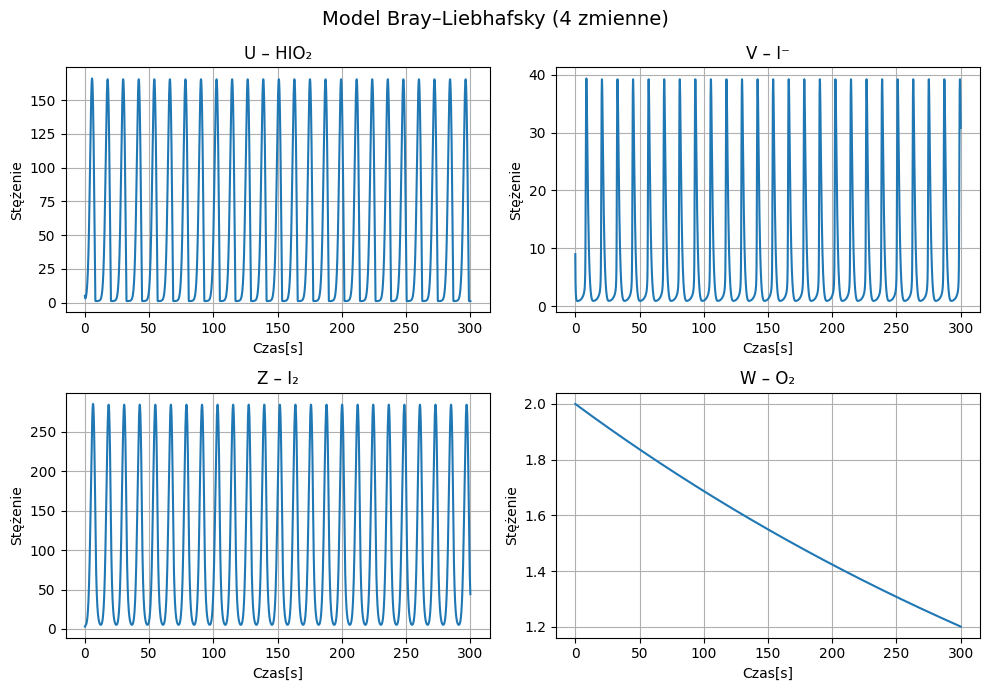

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.691e-04 ...  3.000e+02  3.000e+02]
        y: [[ 5.000e+00  4.983e+00 ...  1.071e+00  1.071e+00]
            [ 9.000e+00  8.966e+00 ...  3.084e+01  3.080e+01]
            [ 3.000e+00  3.005e+00 ...  4.424e+01  4.414e+01]
            [ 2.000e+00  2.000e+00 ...  1.201e+00  1.201e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 181721
     njev: 4932
      nlu: 10836

In [18]:
bl_model(U0, V0, Z0, W0, R1, R2, R3, R4, R5, R6, R7, t_max=300)

In [19]:
U0_2 = np.float64(9) #00
V0_2 = np.float64(5) #95
Z0_2 = np.float64(3)
W0_2 = np.float64(2)

R1_2 = np.float64(1.0035) 
R2_2 = np.float64(1.99) 
R3_2 = np.float64(1) 
R4_2 = np.float64(0.0028) 
R5_2 = np.float64(1.99) 
R6_2 = np.float64(0.0017) 
R7_2 = np.float64(0.02) 


#### Drugi zestaw parametrów

W tym przypadku można zaobserwować brak oscylacji i szybkie ustalenie się stanu równowagi, co również jest możliwe w rzeczywistym przebiegu reakcji.

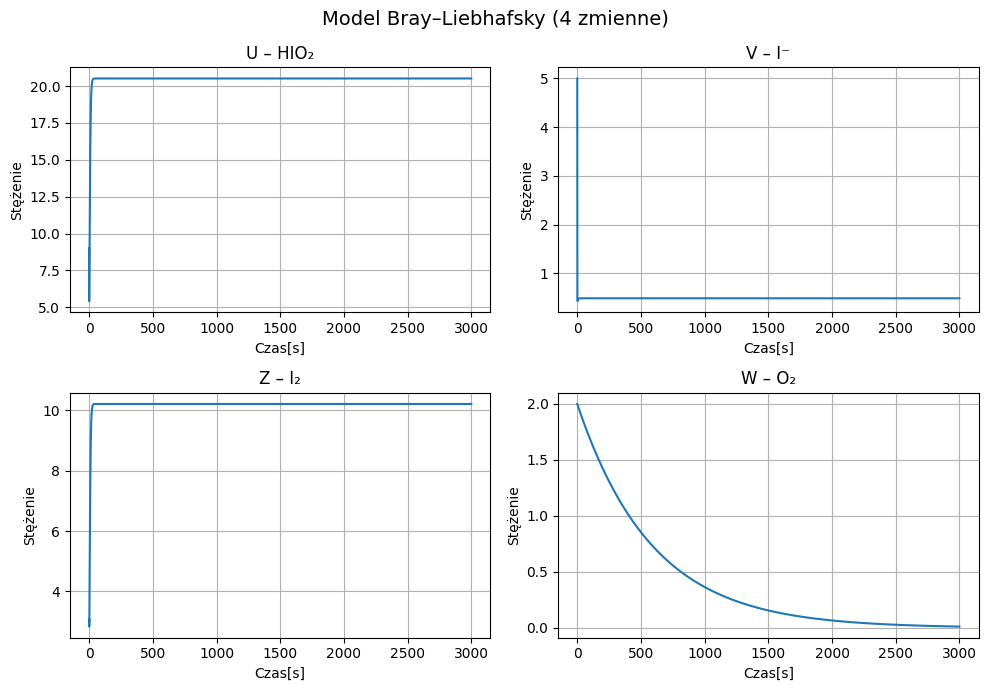

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.384e-04 ...  2.993e+03  3.000e+03]
        y: [[ 9.000e+00  8.967e+00 ...  2.052e+01  2.052e+01]
            [ 5.000e+00  4.961e+00 ...  4.856e-01  4.856e-01]
            [ 3.000e+00  3.001e+00 ...  1.021e+01  1.021e+01]
            [ 2.000e+00  2.000e+00 ...  1.233e-02  1.219e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 6060
     njev: 55
      nlu: 192

In [20]:
bl_model(U0_2, V0_2, Z0_2, W0_2, R1_2, R2_2, R3_2, R4_2, R5_2, R6_2, R7_2)

In [22]:
U0_3 = np.float64(9) #00
V0_3 = np.float64(5) #95
Z0_3 = np.float64(3)
W0_3 = np.float64(2)

R1_3 = np.float64(1.0035) #
R2_3 = np.float64(1) #
R3_3 = np.float64(1) #
R4_3 = np.float64(0.0028) #
R5_3 = np.float64(1) # 1.99 mega dziwny
R6_3 = np.float64(0.0017) # 
R7_3 = np.float64(0.02) # 


#### Trzeci zestaw parametrów

Trzeci zestaw pokazuje krótkie, tłumione, oscylacje, po których szybko ustala się stan równowagi. Jest to najbardziej prawdopodobny obraz zmian stężeń występujących związków, ponieważ nawet po długich i dużych wahaniach w każdym roztworze ustala się stabilny stan równowagi. Warto zauważyć, że mimo takich samych stężeń początkowych, jak w zestawie drugim, stężenia równowagowe związków są inne. 

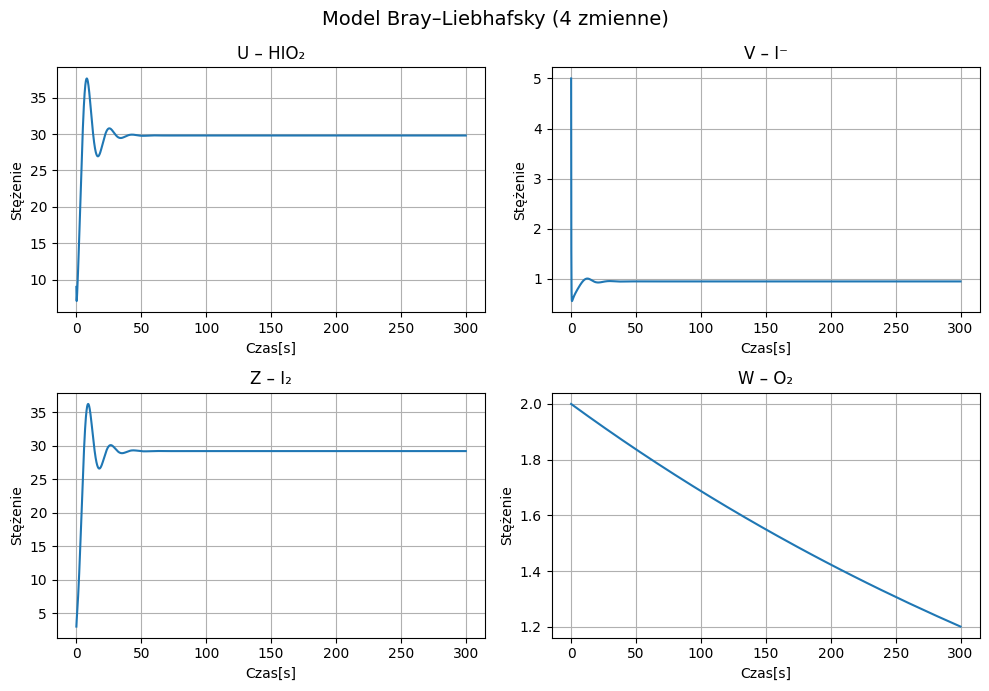

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.169e-04 ...  2.928e+02  3.000e+02]
        y: [[ 9.000e+00  8.981e+00 ...  2.981e+01  2.981e+01]
            [ 5.000e+00  4.971e+00 ...  9.485e-01  9.485e-01]
            [ 3.000e+00  3.004e+00 ...  2.922e+01  2.922e+01]
            [ 2.000e+00  2.000e+00 ...  1.216e+00  1.201e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 6375
     njev: 77
      nlu: 238

In [23]:
bl_model(U0_3, V0_3, Z0_3, W0_3, R1_3, R2_3, R3_3, R4_3, R5_3, R6_3, R7_3, t_max=300)

***
## **5. Porównanie metod numerycznych** <a id="numeryka"></a>

### 5.1 Porównanie rozwiązań <a id="porownanie"></a>
W tej części pokażemy rozwiązania układu równań różniczkowych dla metody Eulera i Rungego-Kutty 4. rzędu, następnie zaprezentujemy jak różnią się rozwiązania równań w zależności od zastosowanej metody numerycznej. W tym celu pokażemy rozwiązania numeryczne uzyskane metodami Eulera, Rungego-Kutty 4 oraz Rungego-Kutty 45. 

In [24]:
def bl_model_euler_rk(
        U0, V0, Z0, W0,
        R1, R2, R3, R4, R5, R6, R7,
        t_max=3000,
        step=0.001,
        rk4=True,
        plot=True
):
    y0 = [U0, V0, Z0, W0]

    n_steps = int(t_max / step)
    if rk4:
        sol_t, sol_y = rk4_method(bray_liebhafsky_model, 0, y0, step, n_steps, (R1, R2, R3, R4, R5, R6, R7))
    else:
        sol_t, sol_y = euler_method(bray_liebhafsky_model, 0, y0, step, n_steps,
                                    (R1, R2, R3, R4, R5, R6, R7))
    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(10, 7))

        axs[0, 0].plot(sol_t, sol_y[:, 0])
        axs[0, 0].set_title('U – HIO₂')

        axs[0, 1].plot(sol_t, sol_y[:, 1])
        axs[0, 1].set_title('V – I⁻')

        axs[1, 0].plot(sol_t, sol_y[:, 2])
        axs[1, 0].set_title('Z – I₂')

        axs[1, 1].plot(sol_t, sol_y[:, 3])
        axs[1, 1].set_title('W – O₂')

        for ax in axs.flat:
            ax.set_xlabel('Czas [s]')
            ax.set_ylabel('Stężenie')
            ax.grid(True)

        fig.suptitle('Model Bray–Liebhafsky (Euler lub RK4)', fontsize=14)
        fig.tight_layout()
        plt.show()
        return sol_t, sol_y
    else:
        return sol_t, sol_y

        
def bl_model_comparssion(U0, V0, Z0, W0, R1, R2, R3, R4, R5, R6, R7, step=0.001, t_max=3000):
    """Porównamy 3 przedstawione modele na wykresach"""
    rk45 = bl_model(U0, V0, Z0, W0, R1, R2, R3, R4, R5, R6, R7, plot=False, t_max=t_max)
    euler_t, euler_y = bl_model_euler_rk(U0, V0, Z0, W0,
                                         R1, R2, R3, R4, R5, R6, R7,
                                         t_max=t_max,
                                         step=step,
                                         rk4=False,
                                         plot=False)
    rk4_t, rk4_y = bl_model_euler_rk(U0, V0, Z0, W0,
                                     R1, R2, R3, R4, R5, R6, R7,
                                     t_max=t_max,
                                     step=step,
                                     rk4=True,
                                     plot=False)

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))

    axs[0, 0].plot(rk45.t, rk45.y[0], label="RK45")
    axs[0, 0].plot(euler_t, euler_y[:, 0], color="orange", label="euler")
    axs[0, 0].plot(rk4_t, rk4_y[:, 0], color="red", label="RK4")
    axs[0, 0].set_title('U – HIO₂')

    axs[0, 1].plot(rk45.t, rk45.y[1])
    axs[0, 1].plot(euler_t, euler_y[:, 1], color="orange")
    axs[0, 1].plot(rk4_t, rk4_y[:, 1], color="red")
    axs[0, 1].set_title('V – I⁻')

    axs[1, 0].plot(rk45.t, rk45.y[2])
    axs[1, 0].plot(euler_t, euler_y[:, 2], color="orange")
    axs[1, 0].plot(rk4_t, rk4_y[:, 2], color="red")
    axs[1, 0].set_title('Z – I₂')

    axs[1, 1].plot(rk45.t, rk45.y[3])
    axs[1, 1].plot(euler_t, euler_y[:, 3], color="orange")
    axs[1, 1].plot(rk4_t, rk4_y[:, 3], color="red")
    axs[1, 1].set_title('W – O₂')
    for ax in axs.flat:
        ax.set_xlabel('Czas [s]')
        ax.set_ylabel('błąd')
        ax.grid(True)
    fig.suptitle('Model Bray–Liebhafsky porównanie metod', fontsize=14)
    fig.tight_layout()
    fig.legend()
    plt.show()
    return None

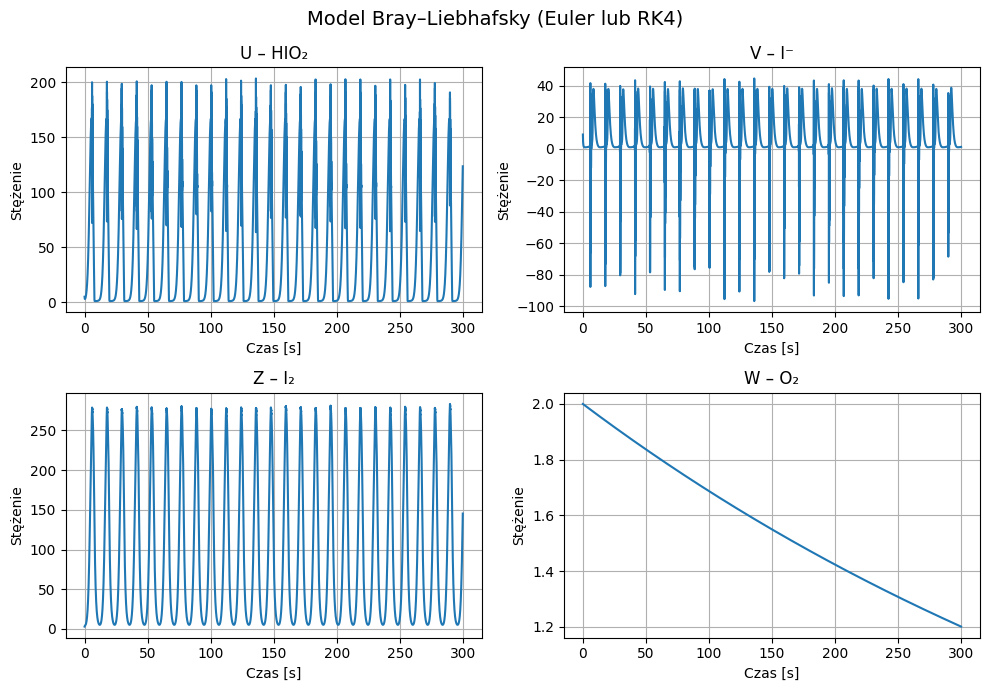

(array([0.00000e+00, 1.60000e-02, 3.20000e-02, ..., 2.99968e+02,
        2.99984e+02, 3.00000e+02], shape=(18751,)),
 array([[  5.        ,   9.        ,   3.        ,   2.        ],
        [  4.582584  ,   8.183496  ,   3.11024   ,   1.9999456 ],
        [  4.25892196,   7.5018407 ,   3.20539036,   1.9998912 ],
        ...,
        [121.56045369,   1.15822342, 142.16877564,   1.20104816],
        [122.53482125,   1.16162076, 143.71906606,   1.2010155 ],
        [123.50489481,   1.16505096, 145.27507961,   1.20098283]],
       shape=(18751, 4)))

In [25]:
bl_model_euler_rk(U0, V0, Z0, W0, R1, R2, R3, R4, R5, R6, R7, step=0.016, t_max=300, rk4 = False)

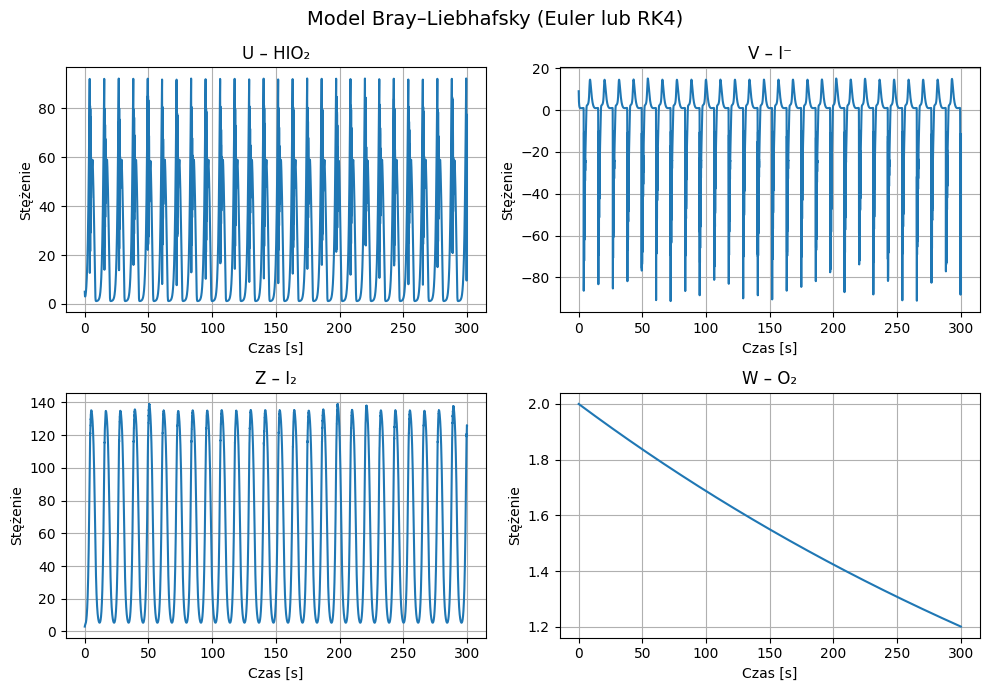

(array([0.0000e+00, 4.0000e-02, 8.0000e-02, ..., 2.9992e+02, 2.9996e+02,
        3.0000e+02], shape=(7501,)),
 array([[  5.        ,   9.        ,   3.        ,   2.        ],
        [  4.20213091,   7.31568076,   3.23580073,   1.999864  ],
        [  3.72561407,   6.12317853,   3.41395565,   1.99972802],
        ...,
        [ 72.09554645, -17.70989535, 124.08997423,   1.2011545 ],
        [ 28.27388388, -62.61006872, 126.10940833,   1.20107283],
        [ 76.81154554, -11.50657718, 126.00153179,   1.20099116]],
       shape=(7501, 4)))

In [26]:
bl_model_euler_rk(U0, V0, Z0, W0, R1, R2, R3, R4, R5, R6, R7, step=0.04, t_max=300, rk4=True)

Jak widać, zastosowanie zbyt dużego kroku czasowego prowadzi do problemów numerycznych w metodzie Eulera oraz metodzie Rungego–Kutty czwartego rzędu. Dla dużych kroków czasowych metody te nie są w stanie poprawnie odwzorować szybkiej dynamiki układu, co prowadzi do niestabilności numerycznej i gwałtownego wzrostu błędów. Zjawisko to jest szczególnie widoczne w przypadku równań reakcji Braya–Liebhafsky’ego, w których część stężeń zmienia się bardzo szybko. W efekcie rozwiązanie traci sens fizyczny $-$ stężenia stają się ujemne. Tego typu równania różniczkowe nazywamy sztywnymi [[12](#ref12)]. Rozwiązaniem tego problemu jest zwiększenie kroku lub zmiana metody na dedykowaną do sztywnych równań różniczkowych. My zmniejszymy krok, aby porównać ze sobą metody. 

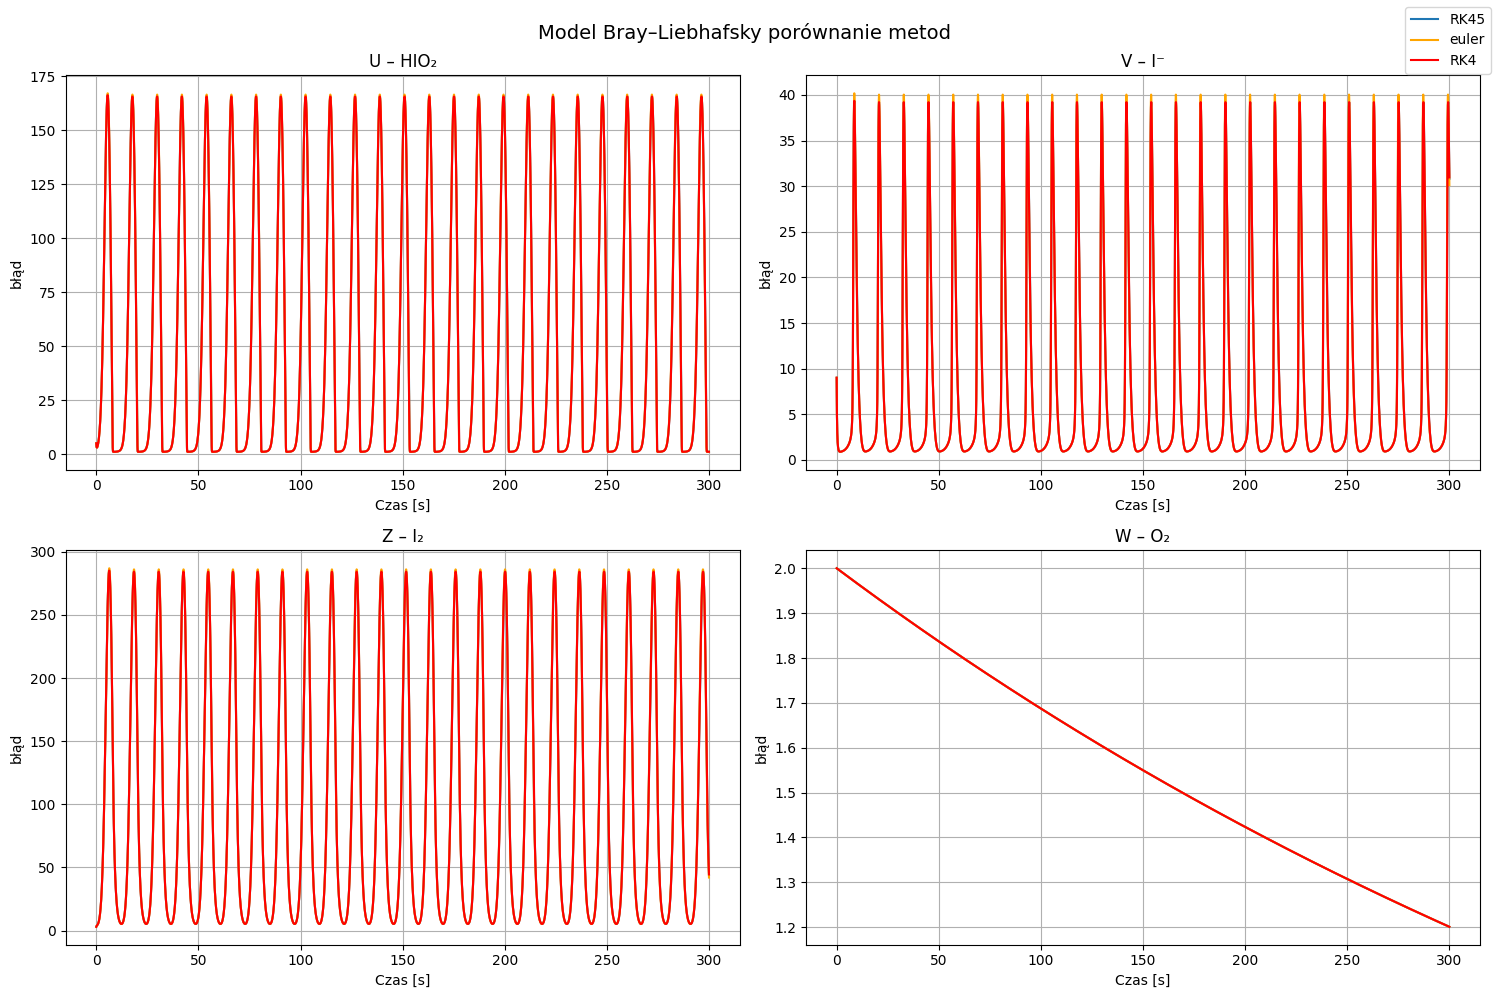

In [27]:
bl_model_comparssion(U0, V0, Z0, W0, R1, R2, R3, R4, R5, R6, R7, step=0.014, t_max=300)

Dopiero dla kroku niższego o rząd wielkości otrzymujemy wyniki podobne jak z pierwszej symulacji metodą RK45.

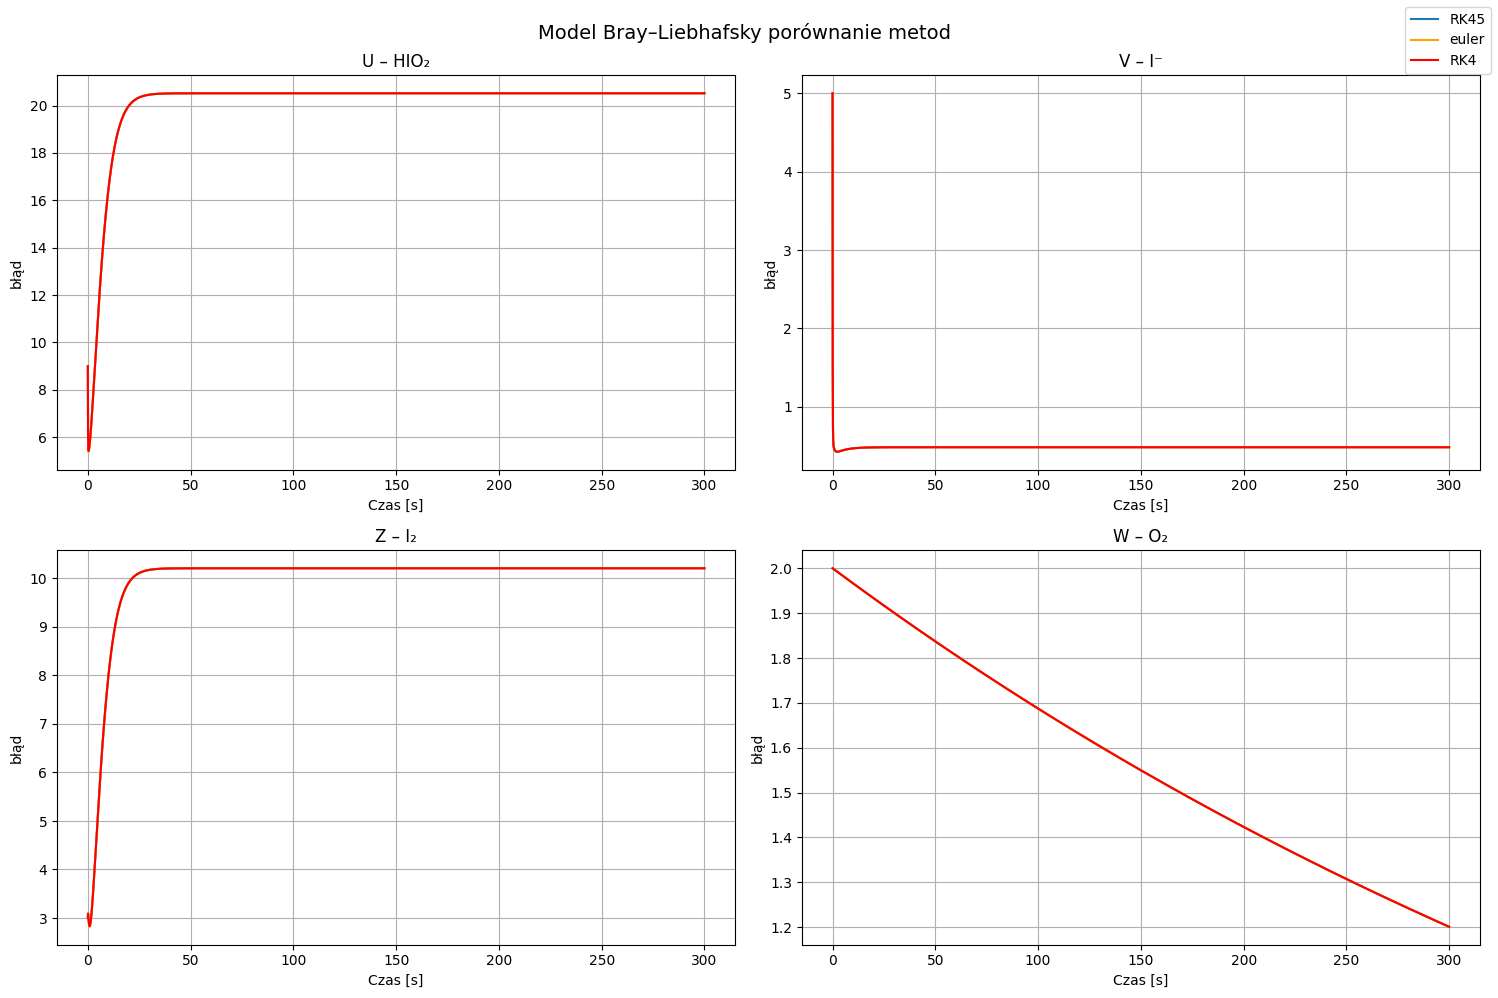

In [28]:
bl_model_comparssion(U0_2, V0_2, Z0_2, W0_2, R1_2, R2_2, R3_2, R4_2, R5_2, R6_2, R7_2, step=0.014, t_max=300)

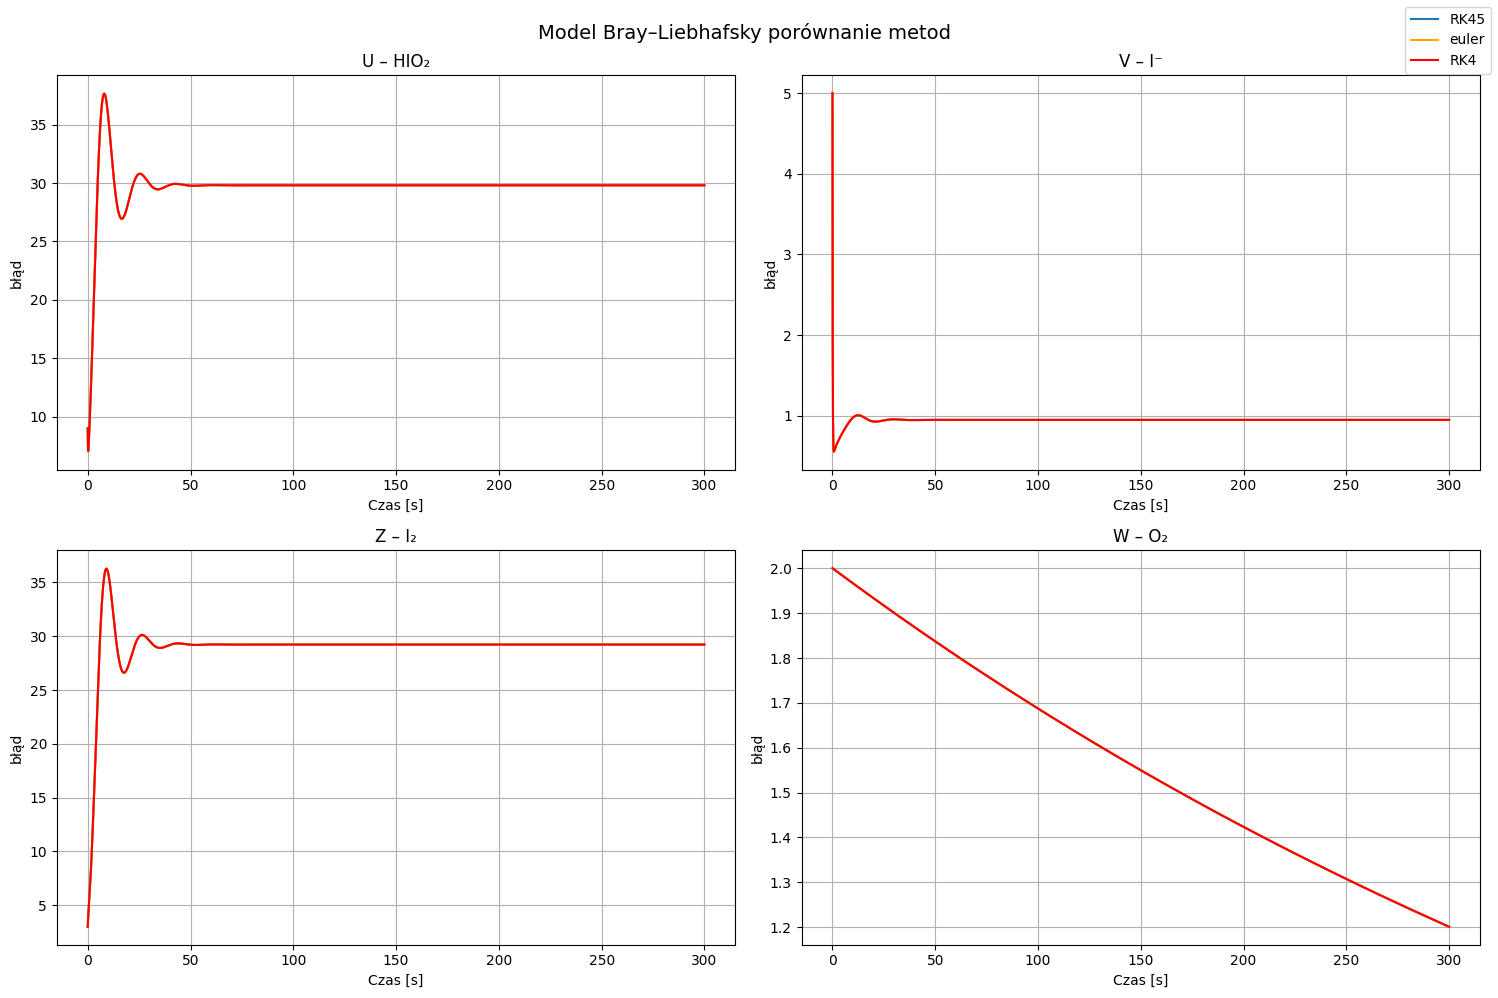

In [29]:
bl_model_comparssion(U0_3, V0_3, Z0_3, W0_3, R1_3, R2_3, R3_3, R4_3, R5_3, R6_3, R7_3, step=0.014, t_max=300)

Dla tak małego kroku różnice w wartościach są niezauważalne. W następnej sekcji porównamy ich błędy. Teraz przeanalizujemy co się stanie z rozwiązanami, jak zwiększymy krok dla parametrów, które nie wywołują oscylacji lub gdy są one tłumione. 

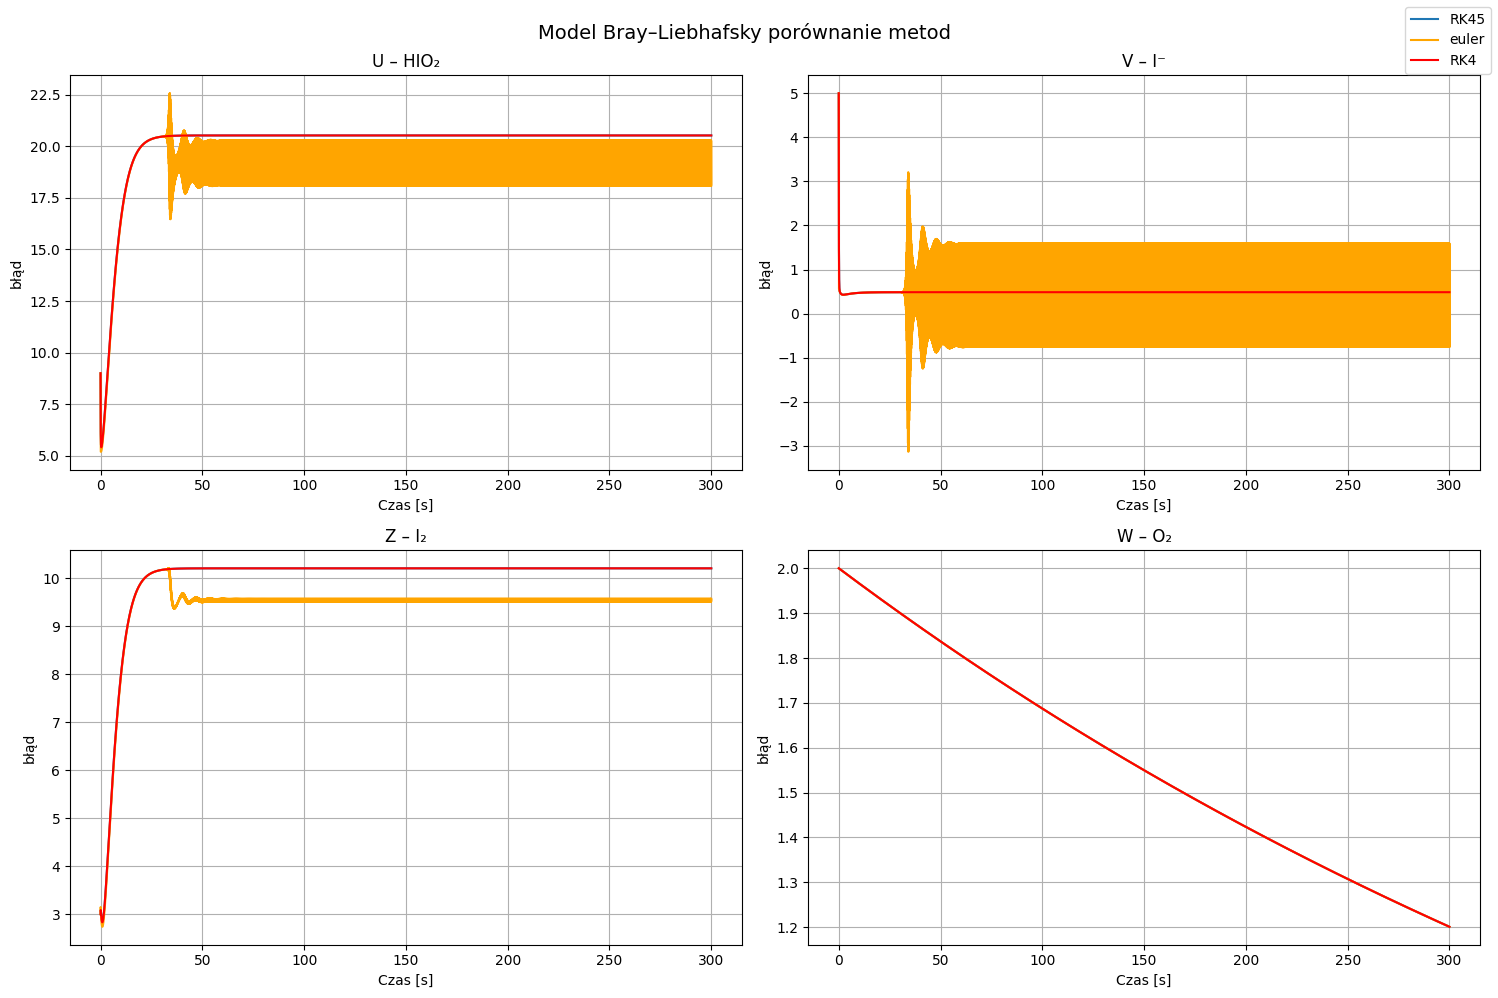

In [30]:
bl_model_comparssion(U0_2, V0_2, Z0_2, W0_2, R1_2, R2_2, R3_2, R4_2, R5_2, R6_2, R7_2, step=0.05, t_max=300)

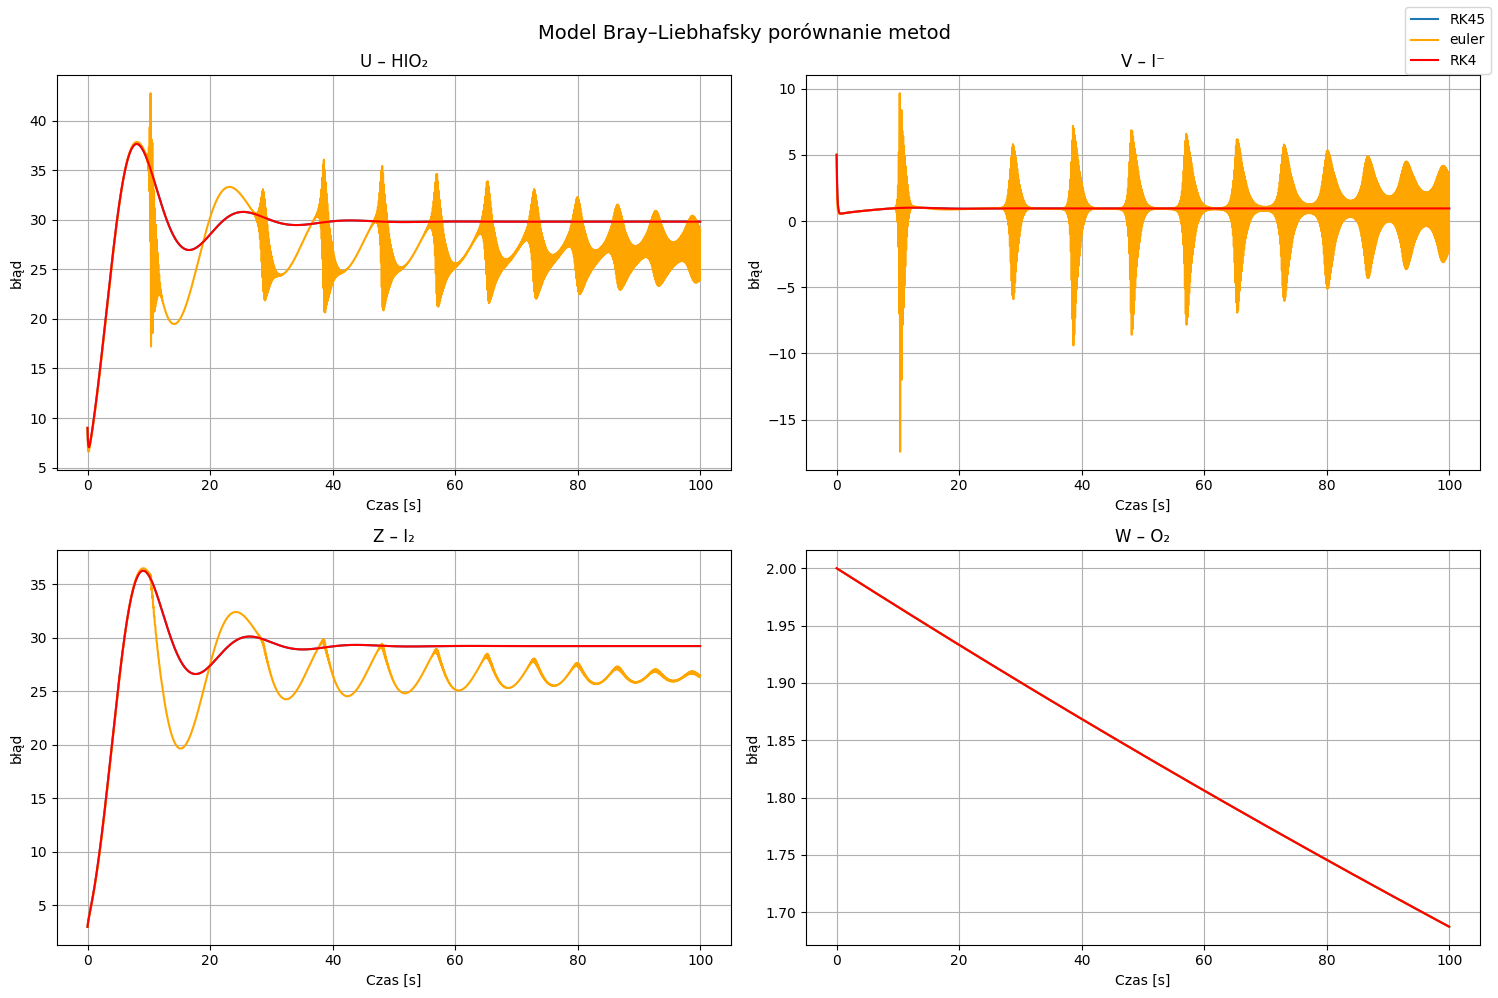

In [31]:
bl_model_comparssion(U0_3, V0_3, Z0_3, W0_3, R1_3, R2_3, R3_3, R4_3, R5_3, R6_3, R7_3, step=0.07, t_max=100)

Z wykresów jasno widać, że metoda Eulera pomimo tego, że nie zwraca błędu jak wcześniej, to wywołuje oscylacje w miejscach w których nie występują, powodując ujemne stężenia. Co więcej metoda Eulera kompletnie zmienia punkt równowagi stężeń. Działa jedynie dobrze dla wykresu stężenia tlenu, który jest eksponentą. Metoda Rungego-Kutty 4. rzędu działa bardzo dobrze, nie sposób rozróżnić krzywe RK4 i RK45.  

### 5.2 Analiza błędów <a id="bledy"></a>

Aby lepiej pokazać różnicę błędów dla metod RK4 i Eulera wyliczymy błąd lokalny, gdzie punktem referencyjnym będzie RK45. Porównamy błędy dla kroku 0.014.

$\text{error} = |y(x_{0}) - y_{ref}(x_{0})|$,

$y  - \text{przybliżenie funkcji w punkcie } x_{0} $,

$y_{ref}  - \text{wartość referencyjna w punkcie } x_{0} $.

Do tego zadania będziemy potrzebowali wyliczyć wartości funckji metodą RK45 oraz metodą Eulera i RK4 dla tych samych punktów, dlatego skorzystamy z parametru *dense_output* w *solve_ivp*. Dzięki niemu będziemy w stanie wyliczyć wartość funkcji w danym punkcie bez stosowania zewnętrznych metod interpolacji.

In [32]:
def compute_errors(
    model_fun,
    y0,
    t_max,
    step,
    args,
    rtol_ref=1e-9,
    atol_ref=1e-12,
    plot=True,
    plot_log=False
):
    """
    Porównanie błędów: Euler vs RK4 względem RK45
    """

    # RK45 (referencja) 
    sol_ref = solve_ivp(
        model_fun,
        (0, t_max),
        y0,
        args=args,
        method="RK45",
        rtol=rtol_ref,
        atol=atol_ref, 
        dense_output= True 
    )
    # Euler
    n_steps = int(t_max / step)
    t_euler, y_euler = euler_method(
        model_fun,
        t0=0,
        y0=y0,
        h=step,
        n_steps=n_steps,
        args=args
    )

    # RK4
    t_rk4, y_rk4 = rk4_method(
        model_fun,
        t0=0,
        y0=y0,
        h=step,
        n_steps=n_steps,
        args=args
    )

    # RK45 na tej samej siatce co euler i rk4
    y_ref = sol_ref.sol(t_euler).T

    # Błędy 
    err_euler = np.abs(y_euler - y_ref)
    err_rk4 = np.abs(y_rk4 - y_ref)
    if plot:
        fig = plt.figure(figsize=(10, 8), layout='constrained')
        subfigs = fig.subfigures(2, 1, hspace=0.1)

        subfigs[0].suptitle('Błąd metody Eulera (wykresy 1-4)', fontsize=14)
        axs0 = subfigs[0].subplots(2, 2)
        axs0[0, 0].plot(t_euler, err_euler[:, 0], color="orange")
        axs0[0, 0].set_title('U – HIO₂')
        axs0[0, 1].plot(t_euler, err_euler[:, 1], color="orange")
        axs0[0, 1].set_title('V – I⁻')
        axs0[1, 0].plot(t_euler, err_euler[:, 2], color="orange")
        axs0[1, 0].set_title('Z – I₂')
        axs0[1, 1].plot(t_euler, err_euler[:, 3], color="orange")
        axs0[1, 1].set_title('W – O₂')
        for ax in axs0.flat:
            ax.set_xlabel('Czas [s]')
            ax.set_ylabel('błąd')
            ax.grid(True)

        subfigs[1].suptitle('Błąd metody Rungego-Kutty (wykresy 5-8)', fontsize=14)
        axs1 = subfigs[1].subplots(2, 2)
        axs1[0, 0].plot(t_rk4, err_rk4[:, 0], color="red")
        axs1[0, 0].set_title('U – HIO₂')
        axs1[0, 1].plot(t_rk4, err_rk4[:, 1], color="red")
        axs1[0, 1].set_title('V – I⁻')
        axs1[1, 0].plot(t_rk4, err_rk4[:, 2], color="red")
        axs1[1, 0].set_title('Z – I₂')
        axs1[1, 1].plot(t_rk4, err_rk4[:, 3], color="red")
        axs1[1, 1].set_title('W – O₂')
        for axx in axs1.flat:
            axx.set_xlabel('Czas [s]')
            axx.set_ylabel('błąd')
            axx.grid(True)
        
        plt.show()
    return {
        "t": t_euler,
        "y_ref": y_ref,
        "y_euler": y_euler,
        "y_rk4": y_rk4,
        "err_euler": err_euler,
        "err_rk4": err_rk4
    }


#### Błędy dla pierwszego zbioru parametrów

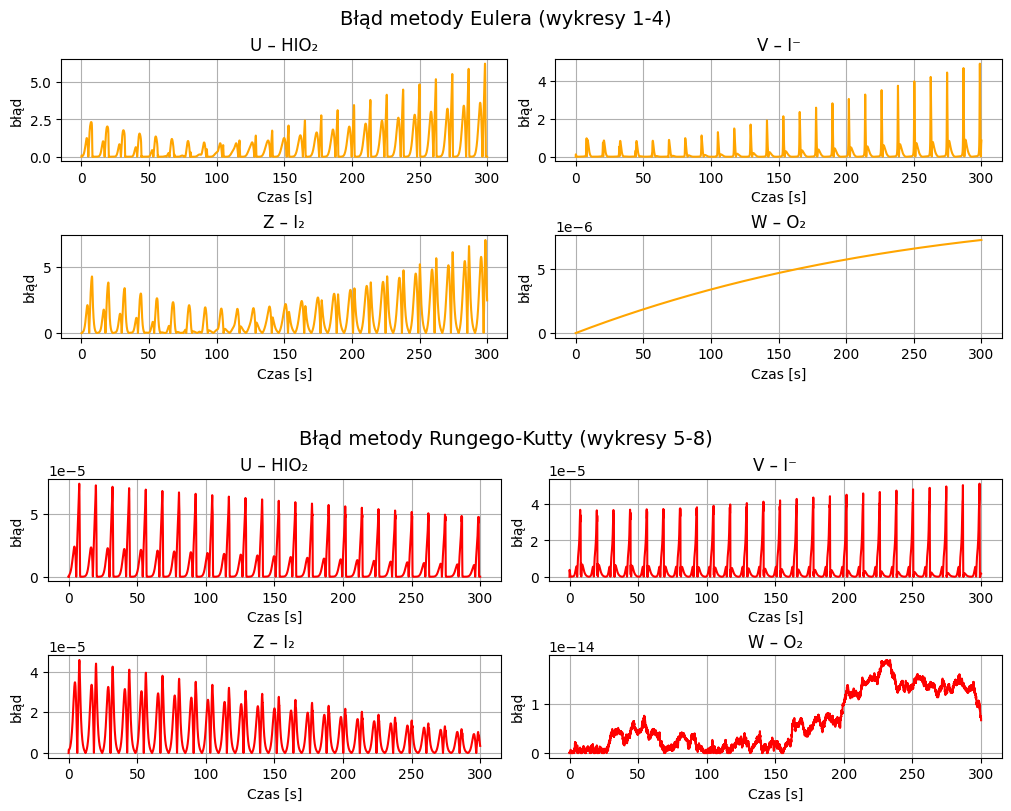

In [33]:
y0 = [U0, V0, Z0, W0]
args = (R1, R2, R3, R4, R5, R6, R7)

errors = compute_errors(
    bray_liebhafsky_model,
    y0=y0,
    t_max=300,
    step=0.014,
    args=args
)


Metoda Eulera ma bardzo wysoki błąd lokalny, biorąc pod uwagę wartości początkowych stężeń $(U_{0} = 9, V_{0} = 5, Z_{0}= 3, W_{0}=2)$. Widać, że błąd w metodzie Rungego-Kutty jest o pięć rzędów niższy. A na wykresie tlenu który jest opisywany przez proste równanie różniczkowe $\dfrac{\text{d}W}{\text{d}t} = -R_{6}W$ obie metody radzą sobie bardzo dobrze mając błąd w okolicy 1e-5 (Euler) i 1e-14 (RK4). W reszcie wykresów wyższe poziomy błędów są spowodowane występowaniem oscylacji. Sprawdźmy błędy dla dłuższego czasu trwania symulacji. 

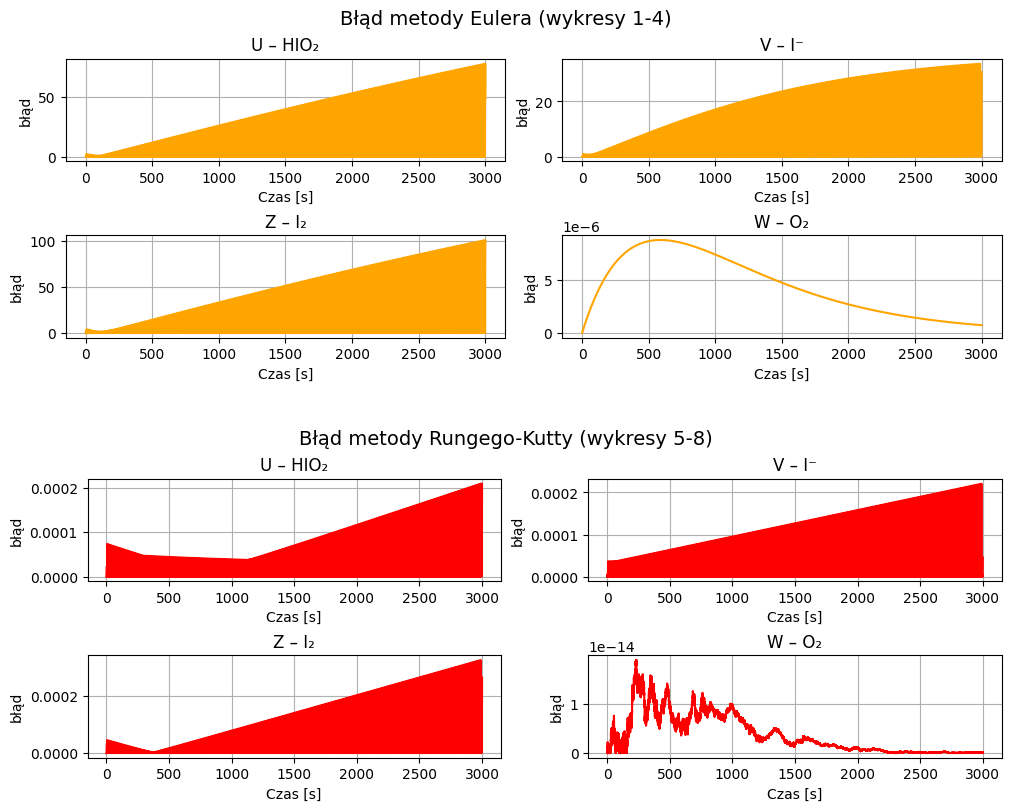

In [34]:
errors = compute_errors(
    bray_liebhafsky_model,
    y0=y0,
    t_max=3000,
    step=0.014,
    args=args
)

Na dłuższej symulacji widać, że wykres błędu dla tlenu w obu przypadkach zbliża się do 0. Natomiast dla reszty reakcji błąd róśnie liniowo z czasem, zachowując oscylacje. 

#### Błędy dla drugiego zbioru argumentów

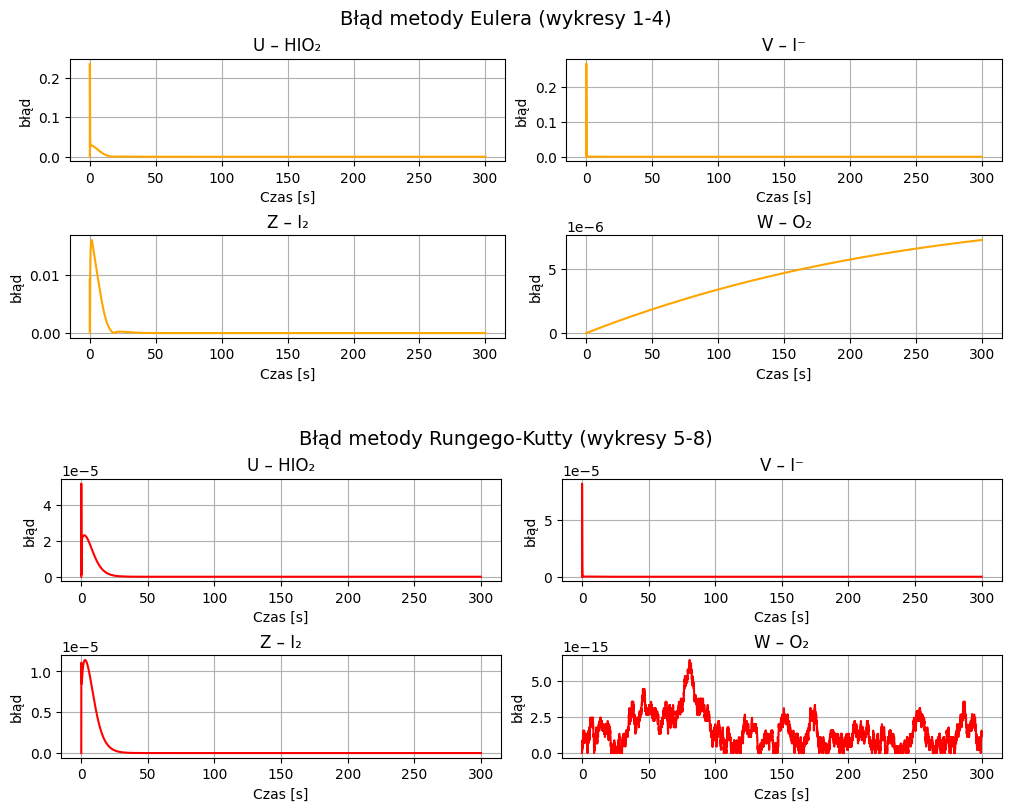

In [35]:
y0 = [U0_2, V0_2, Z0_2, W0_2]
args = (R1_2, R2_2, R3_2, R4_2, R5_2, R6_2, R7_2)

errors = compute_errors(
    bray_liebhafsky_model,
    y0=y0,
    t_max=300,
    step=0.014,
    args=args
)

#### Błędy dla trzeciego zbioru argumentów

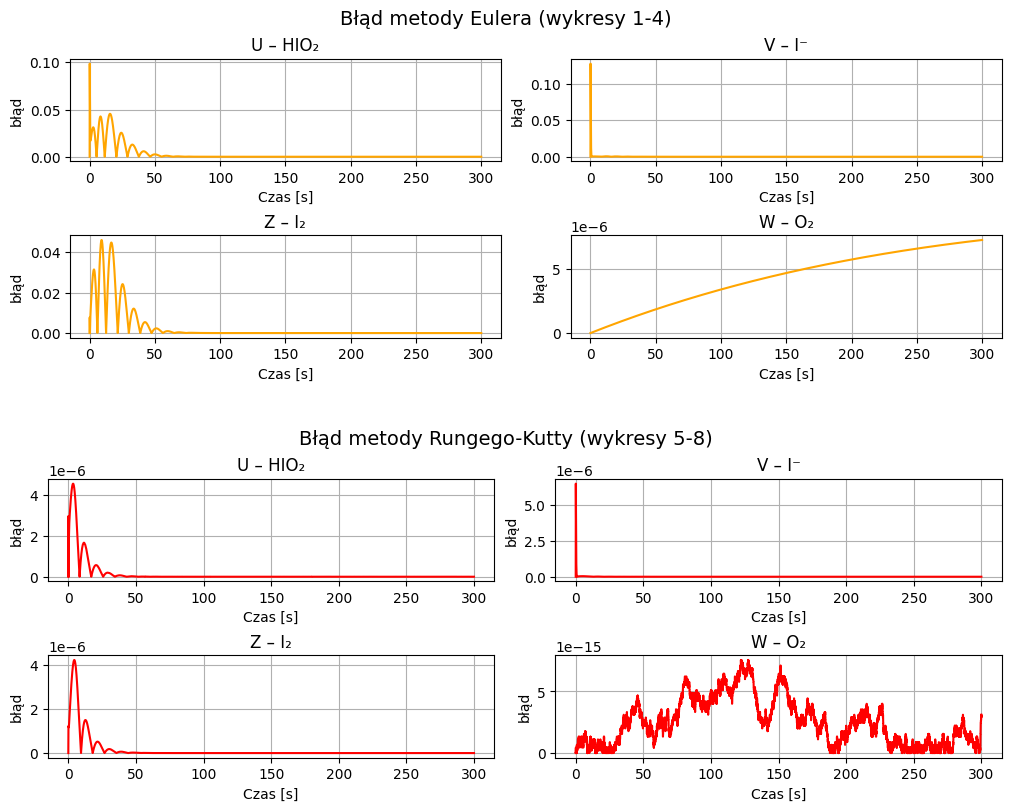

In [36]:
y0 = [U0_3, V0_3, Z0_3, W0_3]
args = (R1_3, R2_3, R3_3, R4_3, R5_3, R6_3, R7_3)

errors = compute_errors(
    bray_liebhafsky_model,
    y0=y0,
    t_max=300,
    step=0.014,
    args=args
)

Dla parametrów dla których nie występują oscylacje w reakcji Braya-Liebhafsky'ego błędy są mniej znaczące, szczególnie dla metody Eulera, dla której błąd nie przekracza 0.2. Pomimo wysokiej niestabilności, przy dostatecznie małym kroku i braku oscylacji, metoda Eulera nie różni się znacząco od metody Rungego-Kutty 4. rzędu. 

***
## **6. Podsumowanie i wnioski** <a id="podsumowanie"></a>

Przybliżyliśmy problem reakcji oscylacyjnych w chemii na przykładzie reakcji Braya-Liebhafsky'ego i przedstawiliśmy jeden z modeli opisujących jej dynamikę. Pokazaliśmy, że możliwe jest uzyskanie modelu zależnego od mniejszej liczby równań niż rzeczywista liczba reakcji elementarnych oraz jak można tworzyć układy równań różniczkowych opisujących zmiany stężeń substancji chemicznych. Zilustrowaliśmy odpowiednimi wykresami, jak przedstawiony model odpowiada rzeczywistym dynamikom układów chemicznych. Opisaliśmy kilka metod numerycznych i sprawdziliśmy, które lepiej nadają się do naszego problemu. Pokazaliśmy, jak model matematyczny upraszcza analizę skomplikowanych reakcji chemicznych.  

Pokazaliśmy, że pojawienie się oscylacji znacząco utrudnia analizę numeryczną. Metoda Eulera nie jest najlepszym wyborem, ze względu na wysoką niestabilność numeryczną oraz duże ryzyko pojawienia się błędów w wynikach (np. NaN). Nieco lepszą decyzją jest metoda Rungego-Kutty 4. rzędu, chociaż nadal występuje niestabilność numeryczna oraz ryzyko błędów dla zbyt dużych kroków. Najlepszą z pośród przedstawionych jest metoda Rungego-Kutty Dormanda-Price'a, ze względu na adaptacyjny krok oraz kontrolę błędów. Jednak przy dłuższych symulacjach, szczególnie w wariancie oscylacyjnym, warto rozważyć metody numeryczne, które są dedykowane do sztywnych równań różniczkowych. 

***
## **7. Bibliografia** <a id="bibliografia"></a>
<a id="ref1"></a> 
[1].  Lawrence K. Forbes, Andrew P. Bassom, Courtney Quinn, "A mathematical model of the Bray–Liebhafsky reaction", data dostępu: 26.12.2025 [link](https://royalsocietypublishing.org/rspa/article/480/2290/20230964/66721/A-mathematical-model-of-the-Bray-Liebhafsky)

<a id="ref2"></a>
[2]. Łukasz Płociniczak, "Ordinary differential equations in science and
technology", 3.2. Euler methods, data dostępu: 26.12.2025 [link](https://alfa.im.pwr.edu.pl/~plociniczak/teaching/ode/lecture.pdf)

<a id="ref3"></a>
[3]. Piotr Fronczak, "Metody numeryczne", data dostępu: 17.01.2026 [link](https://www.if.pw.edu.pl/~agatka/numeryczne/wyklad_08.pdf)

<a id="ref4"></a>
[4]. L. W. Shampine, “Some Practical Runge-Kutta Formulas”, Mathematics of Computation, Vol. 46, No. 173, pp. 135-150, 1986.

<a id="ref5"></a>
[5]. Aleksander Kufelnicki, Marian J. Surma, "Chemia fizyczna : (wykłady) : skrypt dla studentów Wydziału Farmaceutycznego i Oddziału Medycyny Laboratoryjnej", data dostępu: 31.12.2025 [link](https://cybra.lodz.pl/dlibra/publication/14769/edition/11761/content)

<a id="ref6"></a>
[6]. Ewa Gudowska-Nowak, "Reakcje oscylacyjne", data dostępu: 31.12.2025 [link](https://foton.if.uj.edu.pl/documents/12579485/505ff143-d76b-469e-8911-a0bfee7ddb09)

<a id="ref7"></a>
[7]. William C. Bray, "A periodic reaction in homogeneous solution and its relation to catalysis", data dostępu: 3.01.2026 [link](https://pubs.acs.org/doi/abs/10.1021/ja01439a007)

<a id="ref8"></a>
[8]. William C. Bray, Herman Liebhafsky, "Reactions involving hydrogen peroxide, iodine and iodate ion", data dostępu: 4.01.2026 [link](https://pubs.acs.org/doi/abs/10.1021/ja01352a006)

<a id="ref9"></a>
[9]. Maria Litwin, Szarota Styka-Wlazło, Joanna Szymońska, "To jest chemia 1: Chemia ogólna i nieorganiczna", Zakres rozszerzony, data wydania: 2019

<a id="ref10"></a>
[10]. Dokumentacja *solve_ivp*, data dostępu: 12.01.2026 [link](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)

<a id="ref11"></a>
[11]. Erwin Kreyszig, "Advanced Engineering Mathematics", chap. 19 Numerics in general.

<a id="ref12"></a>
[12]. Erwin Kreyszig, "Advanced Engineering Mathematics", Methods for first order ODE's.

[*Wróć do początku*](#spistresci)